# Lesson 3.7 — Compressible Flow

## When Density Changes Matter

All of Module 2 assumed $\rho = $ const (incompressible). This breaks down when:

- Flow speed exceeds Mach 0.3 ($M = u/c_s$, where $c_s = \sqrt{\gamma p / \rho}$ is the speed of sound)
- Large temperature differences exist (heating/cooling changes density)
- Shocks are present (density jumps discontinuously across a shock)

For supersonic flow ($M > 1$), information cannot travel upstream — the pressure Poisson
approach of Module 2 breaks down completely. We need a different formulation.

---

## The Euler Equations (Inviscid Compressible Flow)

The compressible Euler equations in conservation form:

$$\frac{\partial \mathbf{U}}{\partial t} + \frac{\partial \mathbf{F}}{\partial x} + \frac{\partial \mathbf{G}}{\partial y} = 0$$

where the conserved vector and fluxes are:

$$\mathbf{U} = \begin{pmatrix}\rho \\ \rho u \\ \rho v \\ \rho E\end{pmatrix}, \quad
\mathbf{F} = \begin{pmatrix}\rho u \\ \rho u^2 + p \\ \rho u v \\ (\rho E + p)u\end{pmatrix}, \quad
\mathbf{G} = \begin{pmatrix}\rho v \\ \rho u v \\ \rho v^2 + p \\ (\rho E + p)v\end{pmatrix}$$

The pressure is closed by the **ideal gas equation of state**:

$$p = (\gamma - 1)\left(\rho E - \frac{\rho(u^2 + v^2)}{2}\right)$$

with $\gamma = 1.4$ for air (ratio of specific heats).

---

## The Riemann Problem

The key building block of compressible FVM is the **Riemann problem**: given two constant
states $U_L$ and $U_R$ on either side of a cell face, what flux $F$ should we assign?

The exact Riemann solver (Godunov, 1959) is expensive. Approximate Riemann solvers:

- **Roe's solver**: linearizes the Jacobian at an average state — fast and accurate.
- **HLLE/HLLC**: uses wave-speed estimates — simpler and more robust.
- **Lax-Friedrichs**: simplest but most diffusive.

---

## Mach Number Regimes

| Regime | Mach range | Characteristics |
|--------|-----------|------------------|
| Subsonic | $M < 0.3$ | Incompressible; ignore density changes |
| Transonic | $0.3 < M < 1$ | Compressibility important; no shock (in open flow) |
| Sonic | $M = 1$ | Flow choked at throat; shock formation threshold |
| Supersonic | $M > 1$ | Oblique shocks; expansion fans; elliptic → hyperbolic |
| Hypersonic | $M > 5$ | Extreme heating; real gas effects; ionisation |

---

## Normal Shock Relations

Across a normal shock, Rankine-Hugoniot conditions give:

$$\frac{\rho_2}{\rho_1} = \frac{(\gamma+1)M_1^2}{(\gamma-1)M_1^2 + 2}$$

$$\frac{p_2}{p_1} = \frac{2\gamma M_1^2 - (\gamma-1)}{\gamma+1}$$

$$M_2^2 = \frac{(\gamma-1)M_1^2 + 2}{2\gamma M_1^2 - (\gamma-1)}$$

The shock is a mathematical discontinuity — in numerical CFD, it smears over 2-5 cells
depending on the scheme.


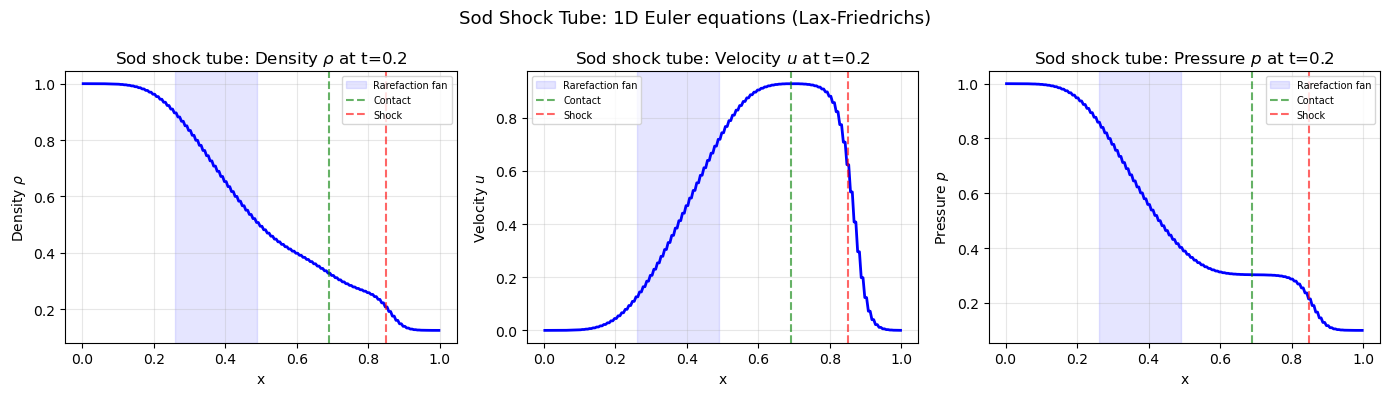

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1D Euler equations: Sod shock tube test
# Classic benchmark: left state (high p,rho) meets right state (low p,rho)

gamma = 1.4

def primitives_to_conserved(rho, u, p):
    E = p/(gamma-1)/rho + 0.5*u**2
    return np.array([rho, rho*u, rho*E])

def conserved_to_primitives(U):
    rho = U[0]
    u   = U[1] / rho
    E   = U[2] / rho
    p   = (gamma - 1) * rho * (E - 0.5*u**2)
    return rho, u, p

def euler_flux(U):
    rho, u, p = conserved_to_primitives(U)
    E = U[2] / rho
    return np.array([rho*u, rho*u**2 + p, (rho*E + p)*u])

def lax_friedrichs_flux(UL, UR, dx, dt):
    return 0.5*(euler_flux(UL) + euler_flux(UR)) - 0.5*(dx/dt)*(UR - UL)

# Grid
N  = 200
L  = 1.0
dx = L / N
x  = np.linspace(dx/2, L - dx/2, N)

# Sod initial conditions
U = np.zeros((3, N))
for i, xi in enumerate(x):
    if xi < 0.5:
        U[:, i] = primitives_to_conserved(1.0, 0.0, 1.0)    # left: high pressure
    else:
        U[:, i] = primitives_to_conserved(0.125, 0.0, 0.1)  # right: low pressure

# Time march
T   = 0.2
t   = 0.0
CFL = 0.4

while t < T:
    # Compute wave speeds for time step
    rho, u, p = conserved_to_primitives(U)
    a = np.sqrt(np.maximum(gamma * p / rho, 1e-10))
    S_max = np.max(np.abs(u) + a)
    dt = CFL * dx / S_max
    dt = min(dt, T - t)
    
    # Fluxes at cell faces using Lax-Friedrichs
    F_faces = np.zeros((3, N+1))
    # Left BC: zero-gradient
    F_faces[:, 0]  = lax_friedrichs_flux(U[:, 0],  U[:, 0],  dx, dt)
    # Right BC
    F_faces[:, -1] = lax_friedrichs_flux(U[:, -1], U[:, -1], dx, dt)
    # Interior faces
    for i in range(1, N):
        F_faces[:, i] = lax_friedrichs_flux(U[:, i-1], U[:, i], dx, dt)
    
    # Update
    U -= dt/dx * (F_faces[:, 1:] - F_faces[:, :-1])
    t += dt

rho_f, u_f, p_f = conserved_to_primitives(U)

# Exact Sod solution (simplified reference)
# Using known positions of waves at t=0.2:
#   Rarefaction fan: x in [0.263, 0.486]
#   Contact discontinuity: x ~ 0.685
#   Shock: x ~ 0.851

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels = ['Density $\\rho$', 'Velocity $u$', 'Pressure $p$']
fields = [rho_f, u_f, p_f]

for ax, field, label in zip(axes, fields, labels):
    ax.plot(x, field, 'b-', linewidth=2)
    ax.set_xlabel('x'); ax.set_ylabel(label)
    ax.set_title(f'Sod shock tube: {label} at t={T}')
    ax.grid(True, alpha=0.3)
    # Annotate wave structures
    ax.axvspan(0.26, 0.49, alpha=0.1, color='blue', label='Rarefaction fan')
    ax.axvline(0.69, color='green', linestyle='--', alpha=0.6, label='Contact')
    ax.axvline(0.85, color='red', linestyle='--', alpha=0.6, label='Shock')
    ax.legend(fontsize=7)

plt.suptitle('Sod Shock Tube: 1D Euler equations (Lax-Friedrichs)', fontsize=13)
plt.tight_layout()
plt.show()

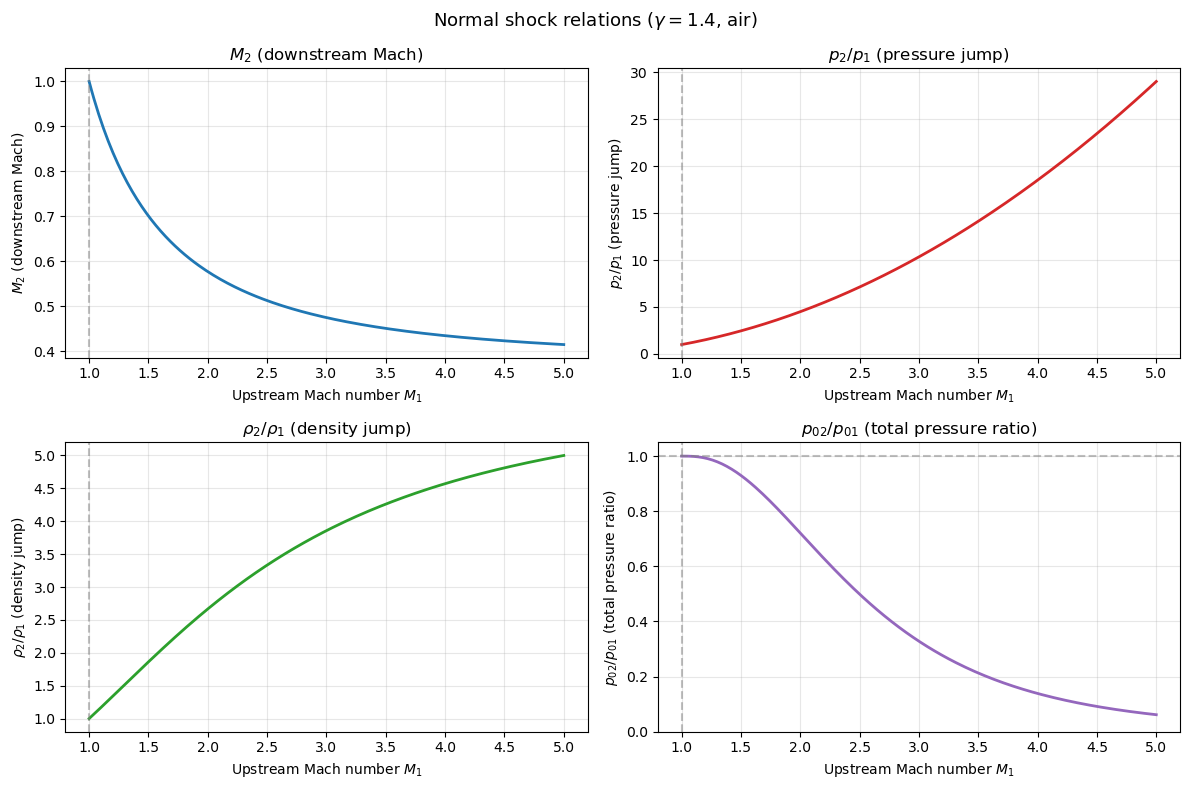

M1=1.5: p2/p1=2.46, rho2/rho1=1.86, M2=0.701
M1=2.0: p2/p1=4.50, rho2/rho1=2.67, M2=0.577
M1=3.0: p2/p1=10.33, rho2/rho1=3.86, M2=0.475
M1=5.0: p2/p1=29.00, rho2/rho1=5.00, M2=0.415


In [2]:
# Normal shock relations: properties across a shock

gamma = 1.4
M1_range = np.linspace(1.0, 5.0, 200)

# Density ratio
rho_ratio = (gamma+1)*M1_range**2 / ((gamma-1)*M1_range**2 + 2)
# Pressure ratio
p_ratio = (2*gamma*M1_range**2 - (gamma-1)) / (gamma+1)
# Downstream Mach
M2 = np.sqrt(((gamma-1)*M1_range**2 + 2) / (2*gamma*M1_range**2 - (gamma-1)))
# Total pressure ratio (entropy production)
p0_ratio = (((gamma+1)*M1_range**2 / ((gamma-1)*M1_range**2 + 2))**(gamma/(gamma-1))
            * ((gamma+1) / (2*gamma*M1_range**2 - (gamma-1)))**(1/(gamma-1)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (axes[0,0], M2, '$M_2$ (downstream Mach)', 'Tab:blue'),
    (axes[0,1], p_ratio, '$p_2/p_1$ (pressure jump)', 'Tab:red'),
    (axes[1,0], rho_ratio, '$\\rho_2/\\rho_1$ (density jump)', 'Tab:green'),
    (axes[1,1], p0_ratio, '$p_{02}/p_{01}$ (total pressure ratio)', 'Tab:purple'),
]

for ax, field, label, color in plots:
    ax.plot(M1_range, field, color=color, linewidth=2)
    ax.set_xlabel('Upstream Mach number $M_1$')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.axvline(1.0, color='gray', linestyle='--', alpha=0.5)

axes[1,1].set_ylim(0, 1.05)
axes[1,1].axhline(1.0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Normal shock relations ($\\gamma = 1.4$, air)', fontsize=13)
plt.tight_layout()
plt.show()

# Print some key values
for M1 in [1.5, 2.0, 3.0, 5.0]:
    p_r = (2*gamma*M1**2 - (gamma-1)) / (gamma+1)
    rho_r = (gamma+1)*M1**2 / ((gamma-1)*M1**2 + 2)
    M2_v = np.sqrt(((gamma-1)*M1**2 + 2) / (2*gamma*M1**2 - (gamma-1)))
    print(f"M1={M1:.1f}: p2/p1={p_r:.2f}, rho2/rho1={rho_r:.2f}, M2={M2_v:.3f}")

## Key Takeaways

- Compressible flow ($M > 0.3$): density changes, pressure waves travel at finite speed $c_s$.
- Governing equations: conservation of mass, momentum, **energy** (all coupled through $\rho$).
- Closed by ideal gas equation of state: $p = (\gamma-1)(\rho E - \frac{1}{2}\rho u^2)$.
- Shocks are discontinuities captured numerically using approximate Riemann solvers (Roe, HLLC).
- Normal shock: increases $p$, $\rho$, $T$; decreases $M$, total pressure (entropy production).
- Sod shock tube is the standard 1D benchmark for compressible solvers.

---

**Next**: Lesson 3.8 — Physics-Informed Neural Networks (PINNs): ML meets CFD.
